<a href="https://colab.research.google.com/github/Elkin535/A---HEURISTICA---Teoria-juego/blob/main/Halc%C3%B3n_vs_Paloma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

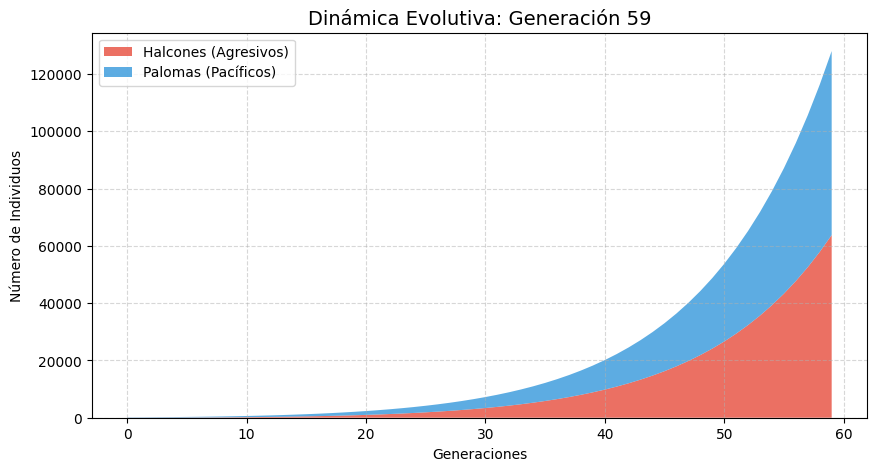

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
import time

def hawk_dove_sim():
    # 1. Configuración de poblaciones iniciales
    hawks = 15  # Agresivos
    doves = 85  # Cooperadores
    history = []

    # Creamos la figura una sola vez para evitar parpadeos
    fig, ax = plt.subplots(figsize=(10, 5))

    for gen in range(60):
        total = hawks + doves
        if total == 0: break

        h_ratio = hawks / total
        d_ratio = doves / total

        # 2. Definición de la Heurística de Éxito (Payoffs)
        # Valor del recurso (V) = 4, Costo de herida (C) = 8
        # Éxito promedio de un Halcón:
        h_fitness = (h_ratio * ((4-8)/2)) + (d_ratio * 4)
        # Éxito promedio de una Paloma:
        d_fitness = (h_ratio * 0) + (d_ratio * (4/2))

        # 3. Actualización de población (Simulación de reproducción)
        # Quien tiene más éxito, crece más en la siguiente generación
        hawks = max(1, hawks + (hawks * h_fitness * 0.1))
        doves = max(1, doves + (doves * d_fitness * 0.1))
        history.append((hawks, doves))

        # 4. Visualización Animada
        ax.clear()
        res = np.array(history)
        gens = range(len(res))

        # Gráfico de área apilada (Visualmente muy claro)
        ax.stackplot(gens, res[:, 0], res[:, 1],
                     labels=['Halcones (Agresivos)', 'Palomas (Pacíficos)'],
                     colors=['#e74c3c', '#3498db'], alpha=0.8)

        ax.set_title(f"Dinámica Evolutiva: Generación {gen}", fontsize=14)
        ax.set_xlabel("Generaciones")
        ax.set_ylabel("Número de Individuos")
        ax.legend(loc='upper left')
        ax.grid(True, linestyle='--', alpha=0.5)

        # Truco de Colab para refrescar la imagen
        ipythondisplay.clear_output(wait=True)
        ipythondisplay.display(fig)
        time.sleep(0.05)

    plt.close() # Cierra la figura final para evitar que se duplique

# Ejecutar la simulación
hawk_dove_sim()